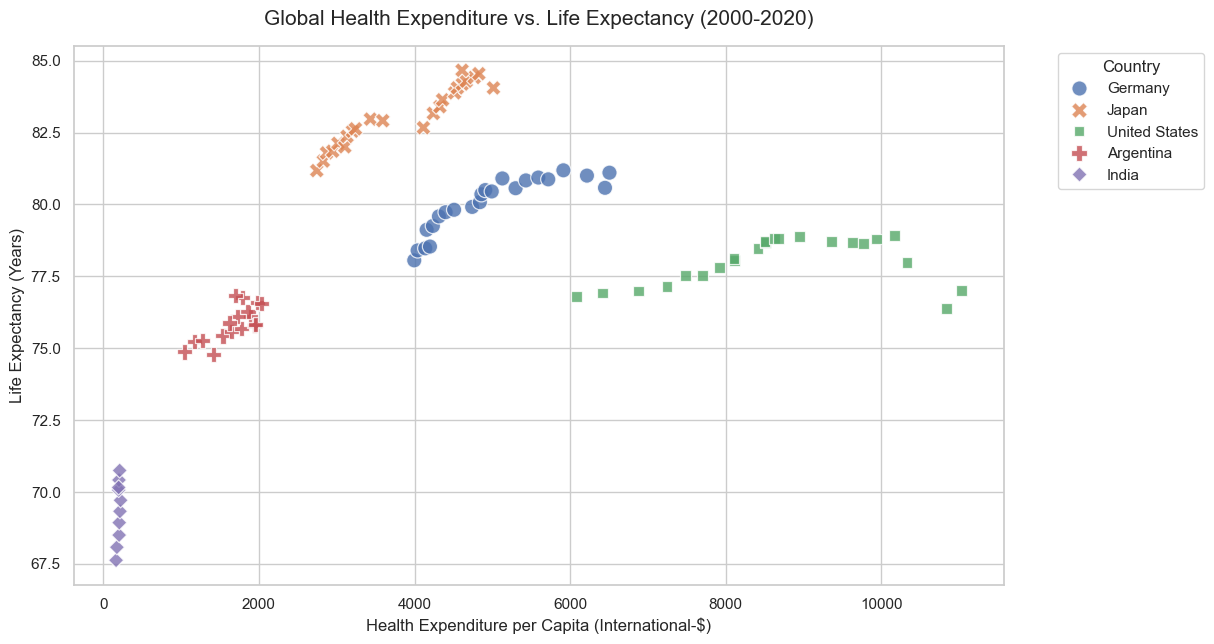

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database
conn = sqlite3.connect("../database/healthcare.db")

# Query multiple target countries
target_countries = ('United States', 'Germany', 'Japan', 'India', 'Argentina')
query = f"""
SELECT country, year, life_expectancy, health_expenditure
FROM health_metrics
WHERE country IN {target_countries}
  AND health_expenditure IS NOT NULL
  AND year >= 2000
ORDER BY year ASC;
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df, 
    x="health_expenditure", 
    y="life_expectancy", 
    hue="country", 
    style="country",
    s=120, 
    alpha=0.8
)

plt.title("Global Health Expenditure vs. Life Expectancy (2000-2020)", fontsize=15, pad=15)
plt.xlabel("Health Expenditure per Capita (International-$)", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')

# Save plot
plt.savefig("../global_health_comparison.png", bbox_inches='tight')
plt.show()